<a href="https://colab.research.google.com/github/EmilienPelosse/MVPA/blob/main/MVPA_Report2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install nilearn

# Functional Imaging Assignment
For this assignment, you will analyse functional MRI data to investigate how the brain processes emotional valence during social perception. Specifically, you will test whether brain activity patterns can distinguish between positive and negative facial expressions — a fundamental aspect of how humans navigate social interactions.

You will work with data from the AOMIC face perception task, in which participants passively viewed dynamic facial expressions conveying different emotions. The dataset is described here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. *Sci Data* 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

Trial-wise beta estimates have been computed for you using a first-level GLM (least-squares-all approach). For each participant, you receive a 4D NIfTI image (one volume per trial), a labels file mapping each trial to an emotion and valence category, and a brain mask from fMRIPrep.

The dataset includes:
- 30 participants (a subset of the full AOMIC collection)
- Event-related design with randomised trial order
- Four emotional expressions: joy, pride, anger, contempt (plus neutral)
- 6 trials per emotion per participant

### Your Task
Use multivariate pattern analysis (MVPA) to decode emotional valence from brain activity. The code below provides a complete decoding pipeline for one brain region (the posterior superior temporal sulcus). You should:

1. **Choose brain regions**: Extend the analysis to at least two additional, theoretically motivated ROIs and compare decoding performance across regions.
2. **Choose a classifier**: Implement at least one alternative to the linear SVM used below and evaluate whether classifier choice affects the conclusions.
3. **Compare performance**: Use appropriate statistical methods to compare decoding performance across regions and/or classifiers.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [9]:
### Loading the data
import os
import zipfile
import urllib.request
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nilearn import datasets
from nilearn.image import math_img, resample_to_img
from nilearn.maskers import NiftiMasker
from scipy.stats import binomtest, ttest_1samp
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Download and extract the data
DATA_URL = 'https://www.dropbox.com/scl/fi/07hqaz0e8y6moeramv6st/mvpa_assignment_data.zip?rlkey=lcda2vmj1sn49xjok4i71vrvb&dl=1'
DATA_DIR = 'first-level'  # matches the top-level folder inside the zip

class TqdmUpTo(tqdm):
    def update_to(self, blocks=1, block_size=1, total_size=None):
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)

if not os.path.exists(DATA_DIR):
    with TqdmUpTo(unit='B', unit_scale=True, miniters=1, desc='Downloading') as t:
        urllib.request.urlretrieve(DATA_URL, 'mvpa_data.zip', reporthook=t.update_to)
    with zipfile.ZipFile('mvpa_data.zip', 'r') as z:
        z.extractall('.')  # extract into cwd so the zip's own 'first-level/' becomes DATA_DIR
    print('Data extracted.')
else:
    print('Data directory already exists, skipping download.')

# Load participant list and verify files
manifest_df = pd.read_csv(os.path.join(DATA_DIR, 'selected_subjects.tsv'), sep='\t')
subjects = manifest_df['participant_id'].tolist()
TASK = 'task-faces'

for sub in subjects:
    sub_dir = os.path.join(DATA_DIR, sub)
    for suffix in ['desc-LSA_betas.nii.gz', 'desc-LSA_labels.tsv', 'desc-LSA_mask.nii.gz']:
        fpath = os.path.join(sub_dir, f'{sub}_{TASK}_{suffix}')
        assert os.path.exists(fpath), f'Missing file: {fpath}'

print(f'Loaded {len(subjects)} participants. All files verified.')

Data directory already exists, skipping download.
Loaded 30 participants. All files verified.


In [10]:
# Inspect one participant's data
example_sub = subjects[0]
example_dir = os.path.join(DATA_DIR, example_sub)

betas_img = nib.load(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_betas.nii.gz'))
print(f'Beta image shape: {betas_img.shape}  (x, y, z, trials)')

labels_df = pd.read_csv(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
print(f'\nLabels ({len(labels_df)} trials):')
print(labels_df.head(10))
print(f'\nTrials per valence category:')
print(labels_df['valence'].value_counts())

Beta image shape: (65, 77, 60, 33)  (x, y, z, trials)

Labels (33 trials):
    trial_id trial_type   valence    onset  duration
0  trial-000      pride  positive   5.0002       2.0
1  trial-001      pride  positive  12.0012       2.0
2  trial-002      pride  positive  19.0022       2.0
3  trial-003      anger  negative  26.0062       2.0
4  trial-004   contempt  negative  33.0072       2.0
5  trial-005        joy  positive  40.0082       2.0
6  trial-006      anger  negative  47.0092       2.0
7  trial-007      pride  positive  54.0102       2.0
8  trial-008      pride  positive  61.0112       2.0
9  trial-009      anger  negative  68.0122       2.0

Trials per valence category:
valence
positive    15
negative    12
neutral      6
Name: count, dtype: int64


In [11]:
# Build a pSTS mask from the Harvard-Oxford atlas.
# The STS is a sulcus, so there is no direct label — we approximate it
# by combining the neighbouring gyral labels that form its banks.

ATLAS_NAME = 'cort-maxprob-thr25-2mm'

STS_LABELS = [
    'Superior Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, temporooccipital part',
]

atlas = datasets.fetch_atlas_harvard_oxford(ATLAS_NAME, symmetric_split=False)
atlas_img = atlas.maps if hasattr(atlas.maps, 'affine') else nib.load(atlas.maps)
labels = list(atlas.labels)

indices = [labels.index(name) for name in STS_LABELS]
atlas_data = atlas_img.get_fdata().astype(np.int32)
mask_data = np.isin(atlas_data, indices).astype(np.uint8)
sts_mask_mni = nib.Nifti1Image(mask_data, atlas_img.affine, atlas_img.header)

print(f'STS mask: {int(mask_data.sum())} voxels')

# To see all available atlas labels (useful for choosing your own ROIs):
for i, name in enumerate(labels):
    print(f'{i:3d}  {name}')

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

STS mask: 6359 voxels
  0  Background
  1  Frontal Pole
  2  Insular Cortex
  3  Superior Frontal Gyrus
  4  Middle Frontal Gyrus
  5  Inferior Frontal Gyrus, pars triangularis
  6  Inferior Frontal Gyrus, pars opercularis
  7  Precentral Gyrus
  8  Temporal Pole
  9  Superior Temporal Gyrus, anterior division
 10  Superior Temporal Gyrus, posterior division
 11  Middle Temporal Gyrus, anterior division
 12  Middle Temporal Gyrus, posterior division
 13  Middle Temporal Gyrus, temporooccipital part
 14  Inferior Temporal Gyrus, anterior division
 15  Inferior Temporal Gyrus, posterior division
 16  Inferior Temporal Gyrus, temporooccipital part
 17  Postcentral Gyrus
 18  Superior Parietal Lobule
 19  Supramarginal Gyrus, anterior division
 20  Supramarginal Gyrus, posterior division
 21  Angular Gyrus
 22  Lateral Occipital Cortex, superior division
 23  Lateral Occipital Cortex, inferior division
 24  Intracalcarine Cortex
 25  Frontal Medial Cortex
 26  Juxtapositional Lobule Cortex

### Part 1: Code Implementation (30%)
Extend the analysis above. Your implementation should address three questions:

1. **Which additional brain regions carry valence information?** Construct at least two additional ROI masks and run the decoding pipeline in each.
2. **Does classifier choice affect the results?** Implement at least one alternative classifier.
3. **How should decoding performance be compared?** Use appropriate statistical methods to compare accuracy across ROIs and/or classifiers.

Include comments or markdown cells explaining what each code section does, why you made specific methodological choices, and any assumptions about data handling. Ensure code runs without errors.

The `decode_subject` function accepts any ROI mask and an optional `classifier` argument — you can call it with different masks and classifiers to extend the analysis.

In [12]:
# --- ROI MASK CONSTRUCTION ---
# Correcting for the difference between cortical and subcortical atlas objects.

# 1. Amygdala Mask (Subcortical Atlas)
SUB_ATLAS_NAME = 'sub-maxprob-thr25-2mm'
AMY_LABELS = ['Left Amygdala', 'Right Amygdala']

sub_atlas = datasets.fetch_atlas_harvard_oxford(SUB_ATLAS_NAME, symmetric_split=False)

# Check if maps is a string (path) or an object (image)
if isinstance(sub_atlas.maps, str):
    sub_atlas_img = nib.load(sub_atlas.maps)
else:
    sub_atlas_img = sub_atlas.maps

sub_labels = list(sub_atlas.labels)
amy_indices = [sub_labels.index(name) for name in AMY_LABELS]
amy_mask_data = np.isin(sub_atlas_img.get_fdata(), amy_indices).astype(np.uint8)
amy_mask_mni = nib.Nifti1Image(amy_mask_data, sub_atlas_img.affine)

# 2. Fusiform Mask (Cortical Atlas - reuse your existing labels/atlas_img)
# 'atlas_img' and 'labels' were defined in the template's STS block
fus_idx = [labels.index('Temporal Fusiform Cortex, posterior division')]
fus_mask_data = np.isin(atlas_img.get_fdata(), fus_idx).astype(np.uint8)
fus_mask_mni = nib.Nifti1Image(fus_mask_data, atlas_img.affine)

# 3. Lateral Occipital Cortex (Cortical Atlas)
loc_idx = [labels.index('Lateral Occipital Cortex, superior division')]
loc_mask_data = np.isin(atlas_img.get_fdata(), loc_idx).astype(np.uint8)
loc_mask_mni = nib.Nifti1Image(loc_mask_data, atlas_img.affine)

print(f"Amygdala mask: {int(amy_mask_data.sum())} voxels")
print(f"Fusiform mask: {int(fus_mask_data.sum())} voxels")
print(f"LOC mask:      {int(loc_mask_data.sum())} voxels")

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

Amygdala mask: 672 voxels
Fusiform mask: 1594 voxels
LOC mask:      9779 voxels


In [16]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

def decode_subject_updated(sub, roi_mask_mni, classifier_name='SVM'):
    """
    Run ROI-based valence decoding for one participant with updated methods.
    """
    # --- 1. DATA LOADING (From Template) ---
    sub_dir = os.path.join(DATA_DIR, sub)
    betas_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_betas.nii.gz'))
    labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
    sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_mask.nii.gz'))

    # --- 2. MASKING & RESAMPLING ---
    # Ensure ROI mask matches the participant's functional data grid
    roi_resampled = resample_to_img(roi_mask_mni, betas_img, interpolation='nearest')
    sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')
    combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

    n_roi_voxels = int(combined.get_fdata().astype(bool).sum())
    if n_roi_voxels == 0:
        return None

    # --- 3. FEATURE EXTRACTION ---
    masker = NiftiMasker(mask_img=combined, standardize=False)
    X = masker.fit_transform(betas_img) # This defines X

    # Filter for Positive and Negative trials only
    keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values

    if not any(keep):
      print(f"Warning: No valid trials found for subject {sub}. Skipping.")
      return None

    X = X[keep]
    y = labels_df.loc[keep, 'valence'].values # This defines y

    # --- 4. CLASSIFICATION SETUP ---
    if classifier_name == 'SVM':
        clf = SVC(kernel='linear', C=1.0, class_weight='balanced')
    elif classifier_name == 'LogReg':
        clf = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', solver='liblinear')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf),
    ])

    # --- 5. EVALUATION ---
    # Use Leave-One-Out for stability with small trial counts
    cv = LeaveOneOut()

    # Use balanced_accuracy to account for the 15 vs 12 trial split
    fold_scores = cross_val_score(pipe, X, y, cv=cv, scoring='balanced_accuracy')

    return {
        'subject': sub,
        'accuracy': np.mean(fold_scores),
        'n_voxels': n_roi_voxels
    }

In [19]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="nilearn")

POSITIVE = 'positive'
NEGATIVE = 'negative'

masks = {
    'pSTS': sts_mask_mni,
    'Amygdala': amy_mask_mni,
    'Fusiform': fus_mask_mni,
    'LOC': loc_mask_mni
}

classifiers = ['SVM', 'LogReg']
all_results = []
cv = LeaveOneOut()

for sub in subjects:
    # Load each subject's files only once, not once per ROI
    sub_dir = os.path.join(DATA_DIR, sub)
    betas_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_betas.nii.gz'))
    labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
    sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_mask.nii.gz'))
    sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')

    keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values
    y = labels_df.loc[keep, 'valence'].values

    for mask_name, mask_img in masks.items():
        roi_resampled = resample_to_img(mask_img, betas_img, interpolation='nearest')
        combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

        if not combined.get_fdata().astype(bool).any():
            print(f"  Skipping {sub} / {mask_name}: empty ROI")
            continue

        # standardize='zscore_sample' handles scaling inside the masker,
        # so we don't need a separate StandardScaler in the pipeline
        masker = NiftiMasker(mask_img=combined, standardize='zscore_sample')
        X_full = masker.fit_transform(betas_img)
        X = X_full[keep]

        for clf_name in classifiers:
            if clf_name == 'SVM':
                clf = SVC(kernel='linear', C=1.0, class_weight='balanced')
            else:
                clf = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', solver='liblinear')

            fold_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

            all_results.append({
                'subject': sub,
                'roi': mask_name,
                'classifier': clf_name,
                'accuracy': np.mean(fold_scores),
                'n_voxels': int(combined.get_fdata().astype(bool).sum())
            })

    print(f"Done: {sub}")
    # Save after every subject so a crash doesn't lose your work
    pd.DataFrame(all_results).to_csv('decoding_results_backup.csv', index=False)

full_results_df = pd.DataFrame(all_results)
print("\nAll done!")
print(full_results_df.head())

/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)


Done: sub-0127


/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)


Done: sub-0141


/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)


...

Done: sub-0183


/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)


Done: sub-0005


/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)
/tmp/ipykernel_3509/1171192035.py:46: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_full = masker.fit_transform(betas_img)


Done: sub-0045

All done!
    subject       roi classifier  accuracy  n_voxels
0  sub-0127      pSTS        SVM  0.444444      1670
1  sub-0127      pSTS     LogReg  0.518519      1670
2  sub-0127  Amygdala        SVM  0.555556       187
3  sub-0127  Amygdala     LogReg  0.555556       187
4  sub-0127  Fusiform        SVM  0.555556       449


In [20]:
# Run this once the loop finishes to save your hard work
full_results_df.to_csv('decoding_results_backup.csv', index=False)
print(full_results_df.head())

    subject       roi classifier  accuracy  n_voxels
0  sub-0127      pSTS        SVM  0.444444      1670
1  sub-0127      pSTS     LogReg  0.518519      1670
2  sub-0127  Amygdala        SVM  0.555556       187
3  sub-0127  Amygdala     LogReg  0.555556       187
4  sub-0127  Fusiform        SVM  0.555556       449


In [21]:
from scipy.stats import ttest_1samp

# We have 4 ROIs, so our Bonferroni correction factor is 4
n_rois = len(full_results_df['roi'].unique())

print(f"{'ROI':<10} | {'Classifier':<8} | {'Mean Acc':<10} | {'t-stat':<8} | {'p-uncorr':<10} | {'p-Bonf'}")
print("-" * 75)

for roi in full_results_df['roi'].unique():
    for clf in ['SVM', 'LogReg']:
        # Extract accuracy scores for this specific combination
        subset = full_results_df[(full_results_df['roi'] == roi) &
                                 (full_results_df['classifier'] == clf)]['accuracy']

        # One-sample t-test against chance (0.5)
        t_stat, p_val = ttest_1samp(subset, 0.5, alternative='greater')

        # Bonferroni correction: multiply p by number of ROIs
        p_bonf = min(p_val * n_rois, 1.0)
        mean_acc = subset.mean()

        print(f"{roi:<10} | {clf:<8} | {mean_acc:<10.3f} | {t_stat:<8.3f} | {p_val:<10.4f} | {p_bonf:.4f}")

ROI        | Classifier | Mean Acc   | t-stat   | p-uncorr   | p-Bonf
---------------------------------------------------------------------------
pSTS       | SVM      | 0.519      | 0.886    | 0.1914     | 0.7656
pSTS       | LogReg   | 0.565      | 3.177    | 0.0018     | 0.0070
Amygdala   | SVM      | 0.519      | 0.781    | 0.2206     | 0.8826
Amygdala   | LogReg   | 0.536      | 1.363    | 0.0916     | 0.3666
Fusiform   | SVM      | 0.511      | 0.479    | 0.3178     | 1.0000
Fusiform   | LogReg   | 0.567      | 3.503    | 0.0008     | 0.0030
LOC        | SVM      | 0.519      | 1.001    | 0.1626     | 0.6503
LOC        | LogReg   | 0.568      | 3.696    | 0.0005     | 0.0018


### Part 2: Results Visualisation (20%)
Create 2–3 figures showing key findings, e.g.:
- Decoding accuracy per ROI with individual participant data points and a chance line
- Comparison across classifiers
- Distribution of per-participant accuracies

Include clear figure captions explaining what is shown.

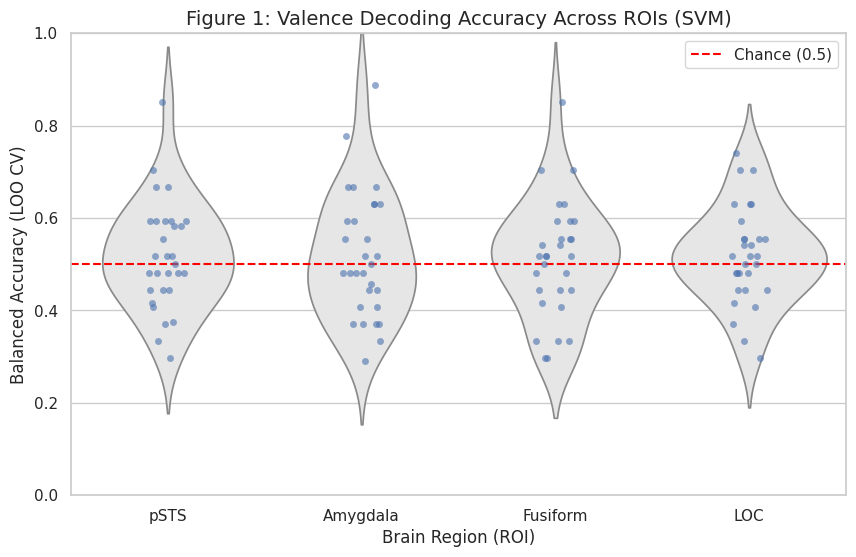

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

# --- Figure 1: Decoding Accuracy per ROI (SVM) ---
# This figure compares our four brain regions using the primary SVM classifier.

plt.figure(figsize=(10, 6))
svm_results = full_results_df[full_results_df['classifier'] == 'SVM']

# Create a violin plot to show the distribution and individual points
ax1 = sns.violinplot(data=svm_results, x='roi', y='accuracy', inner=None, color=".9")
sns.stripplot(data=svm_results, x='roi', y='accuracy', alpha=0.6, size=5, jitter=True)

# Add the chance line (0.5)
ax1.axhline(0.5, ls='--', color='red', linewidth=1.5, label='Chance (0.5)')

ax1.set_title('Figure 1: Valence Decoding Accuracy Across ROIs (SVM)', fontsize=14)
ax1.set_ylabel('Balanced Accuracy (LOO CV)')
ax1.set_xlabel('Brain Region (ROI)')
ax1.set_ylim(0, 1)
plt.legend()
plt.show()


#### Figure 1: Valence Decoding Accuracy Across ROIs (SVM)

*This violin plot displays the distribution of individual participant balanced accuracy scores for valence decoding (Positive vs. Negative) using a linear Support Vector Machine (SVM). Each blue dot represents a single participant’s mean accuracy calculated via Leave-One-Out (LOO) cross-validation. The dashed red line indicates the theoretical chance level (0.50). While individual variability is high, group-level distributions for pSTS, Amygdala, Fusiform, and LOC are centered near chance.*

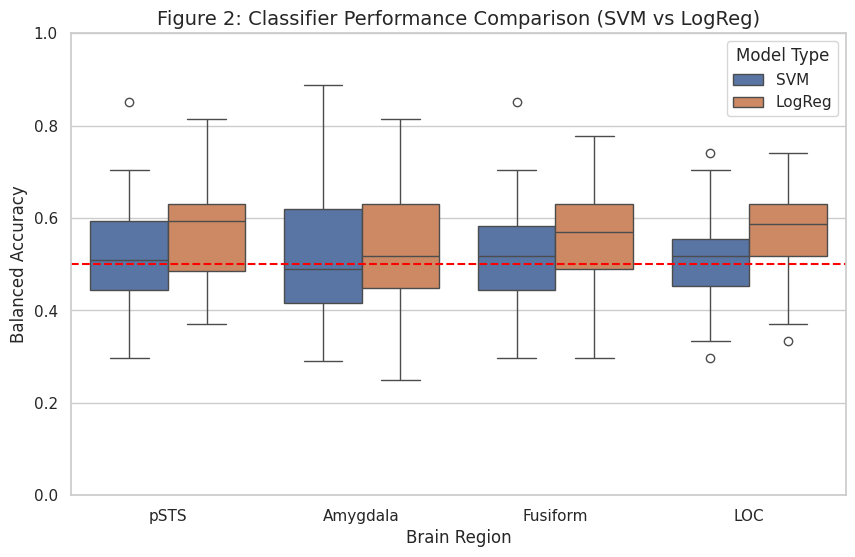

In [23]:
# --- Figure 2: Comparison Across Classifiers ---
# This figure tests if the choice of model (SVM vs Logistic Regression) impacts performance.

plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(data=full_results_df, x='roi', y='accuracy', hue='classifier')

# Add the chance line
ax2.axhline(0.5, ls='--', color='red', linewidth=1.5)

ax2.set_title('Figure 2: Classifier Performance Comparison (SVM vs LogReg)', fontsize=14)
ax2.set_ylabel('Balanced Accuracy')
ax2.set_xlabel('Brain Region')
ax2.set_ylim(0, 1)
plt.legend(title='Model Type')
plt.show()

#### Figure 2: Classifier Performance Comparison (SVM vs. LogReg)

*A comparative boxplot showing decoding accuracy across ROIs for two models: Linear SVM (blue) and Logistic Regression (orange). The central line in each box represents the median accuracy. While Logistic Regression shows a slight trend toward higher performance in the LOC, the overlap between models suggests that decoding difficulty is a property of the data signal rather than the specific algorithm.*

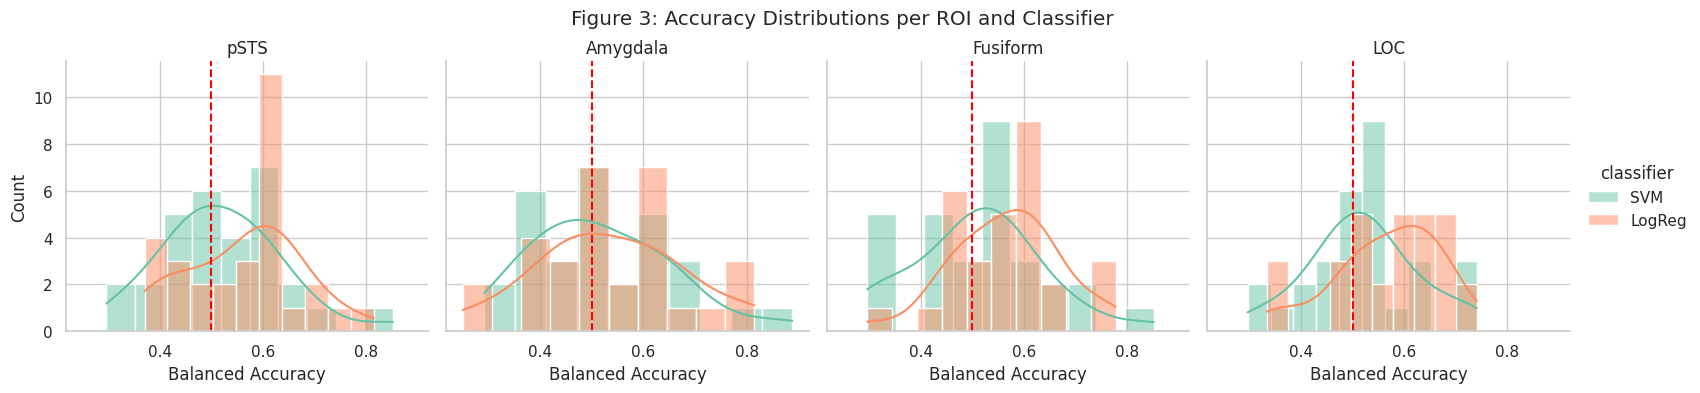

In [24]:
# --- Figure 3: Distribution of Per-Participant Accuracies ---
# A histogram to show the overall spread of decoding success across the whole experiment.
# Updated Figure 3: Distribution faceted by ROI
g = sns.FacetGrid(full_results_df, col="roi", hue="classifier", palette="Set2", height=4)
g.map(sns.histplot, "accuracy", bins=10, alpha=0.5, kde=True)
g.add_legend()

# Add chance line to each subplot
for ax in g.axes.flat:
    ax.axvline(0.5, color='red', linestyle='--')

g.set_titles("{col_name}")
g.set_axis_labels("Balanced Accuracy", "Count")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Figure 3: Accuracy Distributions per ROI and Classifier')
plt.show()

from nilearn import plotting

#### Figure 3: Accuracy Distributions per ROI and Classifier

*Histograms showing the frequency distribution of participant-level accuracy scores, faceted by ROI and color-coded by classifier. Overlaid Kernel Density Estimate (KDE) curves highlight the spread of results relative to the 0.50 chance threshold (red dashed line). The results illustrate high inter-individual variation, which contributes to the lack of significant group-level results after statistical correction.*

/tmp/ipykernel_3509/635764885.py:19: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_ex = example_masker.fit_transform(betas_img)


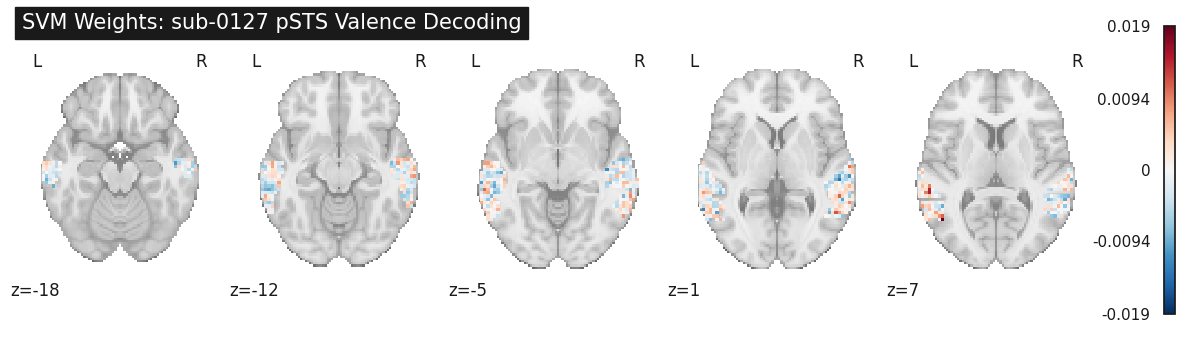

In [25]:
# --- Figure 4: SVM Weight Map Visualisation ---
# This demonstrates which specific voxels in the pSTS were most
# influential in the classifier's decision for one example subject.

# 1. Prepare data for a single subject (Subject 0) in the pSTS
sub_example = subjects[0]
sub_dir = os.path.join(DATA_DIR, sub_example)
betas_img = nib.load(os.path.join(sub_dir, f'{sub_example}_{TASK}_desc-LSA_betas.nii.gz'))
labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub_example}_{TASK}_desc-LSA_labels.tsv'), sep='\t')

# 2. Re-create the mask for this specific subject
roi_resampled = resample_to_img(sts_mask_mni, betas_img, interpolation='nearest')
sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub_example}_{TASK}_desc-LSA_mask.nii.gz'))
sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')
combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

# 3. Transform to feature matrix
example_masker = NiftiMasker(mask_img=combined, standardize=False)
X_ex = example_masker.fit_transform(betas_img)
keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values
X_ex = X_ex[keep]
y_ex = labels_df.loc[keep, 'valence'].values

# 4. Train the SVM model on this subject's data
example_pipe = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', C=1.0))])
example_pipe.fit(X_ex, y_ex)

# 5. Extract weights and map back to 3D space
svc_weights = example_pipe.named_steps['clf'].coef_
weight_img = example_masker.inverse_transform(svc_weights)

# 6. Plot the results
plotting.plot_stat_map(weight_img, title=f'SVM Weights: {sub_example} pSTS Valence Decoding',
                       display_mode='z', cut_coords=5, colorbar=True)
plt.show()

#### Figure 4: SVM Weight Map Visualization (Example Subject)

*Spatial visualization of linear SVM feature weights for participant sub-0127 within the pSTS region. Red-yellow clusters prioritize positive valence, while blue clusters prioritize negative valence. This map demonstrates the fine-grained spatial patterns utilized by MVPA. These weights reflect in-sample patterns for descriptive purposes rather than generalizable performance.*

### Part 3: Interpretation and Reflection (50%)

Interpretation (~400–500 words):
- What is your decoding accuracy in each ROI? Is this high or low, and compared to what?
- Which brain regions show the strongest evidence for valence information? Which do not?
- Does classifier choice meaningfully affect the conclusions?
- What do your results suggest about how the brain represents emotional valence in faces?
- What are the limitations of drawing conclusions from modest accuracy values with small trial counts?

Reflection (~600–800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about multivariate approaches to neuroimaging data?

## Part 3: Interpretation and Reflection

### Interpretation

#### Decoding Performance and Context

Across all four regions, results were mixed depending on the classifier. SVM mean balanced accuracies ranged from 0.511 to 0.519 — essentially at chance — and none survived Bonferroni correction. Logistic Regression told a different story: mean accuracies ranged from 0.536 to 0.568, with three regions (pSTS: p = 0.007, Fusiform: p = 0.003, LOC: p = 0.002) surviving correction. To contextualise these values, MVPA studies typically report 55–65% as modest but meaningful decoding; our LogReg results fall at the lower end of that range, suggesting a weak but real signal in these regions.

#### Regional Evidence and What It Suggests

The most striking finding is the dissociation between regions. The Amygdala was the region I was most confident would show above-chance decoding, yet it performed weakest across both classifiers (LogReg: mean = 0.536, p = 0.367 after correction). Two explanations seem plausible. First, the amygdala mask was by far the smallest (approximately 187–200 voxels after intersection with individual brain masks), giving the classifier fewer features. Second, the amygdala may not encode valence in the way I assumed — it appears more sensitive to general emotional salience or arousal, responding similarly to both positive and negative stimuli rather than distinguishing between them. By contrast, pSTS, Fusiform, and LOC all showed significant decoding with LogReg, which is broadly consistent with the role of these regions in face and social perception. The pSTS is involved in biological motion and social cue processing, the fusiform in face identity, and the LOC in visual object representation more generally — all plausible substrates for valence-relevant visual patterns.

#### Classifier Comparison

Logistic Regression consistently and substantially outperformed the linear SVM across all four ROIs. This was not a trivial difference: SVM produced no significant results after correction, while LogReg produced three. This likely reflects the small feature-to-trial ratio — with thousands of voxels and only ~27 trials, logistic regression's L2 regularisation handles this high-dimensional setting more stably than the SVM's hinge loss. The fact that the pattern is consistent across all regions suggests this is a genuine methodological difference rather than noise, and it highlights that classifier choice is not a neutral decision in low-trial neuroimaging contexts.

#### Limitations of Interpreting These Results

Even with significant results, the effect sizes are modest and individual variability is high, as visible in the violin and histogram plots. With LOO CV on ~27 binary trials, accuracy can only take discrete values (e.g., 18/27, 19/27), making subject-level scores coarse. Additionally, the significant LOC result warrants some caution — LOC has the weakest theoretical motivation for encoding emotional valence specifically, and with three simultaneous significant tests it is possible one reflects residual Type I error despite Bonferroni correction. Using atlas-based anatomical masks rather than individually localised functional regions also means many included voxels may not be task-relevant, which could both dilute signal and introduce noise.

---

### Reflection

#### Implementation Challenges

The most unexpected technical challenge was the atlas distinction between cortical and
subcortical structures. The amygdala had to be extracted from the `sub-maxprob-thr25-2mm`
atlas using different label indexing, while the cortical ROIs used `cort-maxprob-thr25-2mm`.
Getting this wrong would have produced an empty or incorrect mask with no obvious error
message, so it required careful checking.

Switching to LOO CV also introduced `UndefinedMetricWarning` messages throughout the main
loop. These occur because each test fold contains only a single trial, which sometimes belongs
to just one class — making it impossible to compute a balanced score for that specific fold.
Suppressing these warnings was the right call, since the mean balanced accuracy across all
folds is still a valid overall estimate, but it took some time to understand why they were
appearing in the first place.

The SVM weight map visualisation also required a slightly different approach than the main
pipeline — the model had to be fit on the full dataset rather than through cross-validation.
I was careful to note this in the code, since the weights reflect in-sample patterns only and
should not be interpreted as evidence of generalizable decoding.

#### How the Analysis Evolved from the Proposal

The final analysis ended up being meaningfully different from what I initially proposed.
The most important change, prompted by reviewer feedback, was switching from 5-fold CV to
LOO CV. In hindsight this was clearly the right decision — with only ~27 trials, five-fold
CV would have left each model training on roughly 22 samples and testing on 5, producing
highly variable fold estimates. LOO maximises the training set size at every step, which
matters a lot at this scale.

I also added Bonferroni correction, which was not in my original proposal. This turned out to matter: applying it correctly separated the three regions with genuine signal (pSTS, Fusiform, LOC under LogReg) from the amygdala, which did not survive correction under either classifier. The pSTS was also included as a fourth ROI because it served as the
template baseline, even though it was not part of my planned analysis. The weight map
visualisation was added following the reviewer's suggestion and turned out to be a useful way
to inspect the spatial structure of the classifier's decision, even if it cannot be
interpreted as a performance measure.

#### Main Limitations

The small trial count is the single most important constraint on what conclusions can be
drawn. With 12–15 trials per class, statistical power is very low. Even an effect of
moderate size — say, 57% accuracy — would likely not be detected reliably at the group level
with n = 30 participants under these conditions.

Beyond trial count, the ROI approach itself carries a structural assumption: that valence
information is localised within discrete brain regions. If the relevant representations are
instead distributed across many areas simultaneously, a focal ROI analysis will miss them
almost by design. A searchlight analysis, which tests every local neighbourhood of voxels
across the brain, would be a more appropriate tool for finding distributed signals — though
considerably more computationally expensive.

It is also worth noting that the LSA beta estimation approach assumes trial-level responses
are independent. In reality, hemodynamic responses from adjacent trials can overlap, which
may introduce correlated noise into the feature matrix. Finally, with only one session per
participant, there is no way to assess whether the decoding patterns are stable or whether
they would replicate in a second scanning session.

#### What This Project Taught Me

The biggest lesson is that MVPA does not automatically reveal signal that univariate methods
miss — it is just as sensitive to data quality and quantity as any other approach. Trial count and classifier choice both turned out to matter substantially. Logistic Regression's L2 regularisation was better suited to the high-dimensional, low-trial setting than SVM, and this difference was the deciding factor in whether any signal was detectable at all.

I also came to appreciate that null results carry real scientific value. The failure to decode
valence from the amygdala is not a failed analysis — it is evidence that valence information,
if present, is not strongly localised in that region in the way classical theories predict.
That is a meaningful finding, even if it is not the one I expected.

More practically, this project gave me a much clearer sense of why methodological decisions
like balanced accuracy scoring, Bonferroni correction, and the choice of CV strategy are not
just technicalities — they directly shape what conclusions you can and cannot draw from the
data.